In [12]:
import numpy as np
import matplotlib.pyplot as plt
import hoomd

def measure_pair_potential(
    pair_force,
    r_values,
    box_length=30,
    particle_type="A",
    seed=1,
):
    """
    Measure pair potential energy U(r) for two particles using a HOOMD pair force.
    """

    energies = []

    for r in r_values:
        # ----------------------------
        # Two-particle snapshot
        # ----------------------------
        snap = hoomd.Snapshot()
        snap.particles.N = 2
        snap.particles.types = [particle_type]
        snap.particles.typeid[:] = [0, 0]

        snap.configuration.box = [box_length, box_length, box_length, 0, 0, 0]

        snap.particles.position[:] = [
            [-r / 2, 0, 0],
            [ r / 2, 0, 0],
        ]

        # ----------------------------
        # Small temporary simulation
        # ----------------------------
        sim_test = hoomd.Simulation(
            device=hoomd.device.CPU(),
            seed=seed,
        )

        sim_test.create_state_from_snapshot(snap)

        integrator = hoomd.md.Integrator(dt=0.005)
        integrator.forces.append(pair_force)
        sim_test.operations.integrator = integrator

        thermo = hoomd.md.compute.ThermodynamicQuantities(
            filter=hoomd.filter.All()
        )
        sim_test.operations.computes.append(thermo)

        sim_test.run(0)

        energies.append(thermo.potential_energy)

    return np.array(energies)

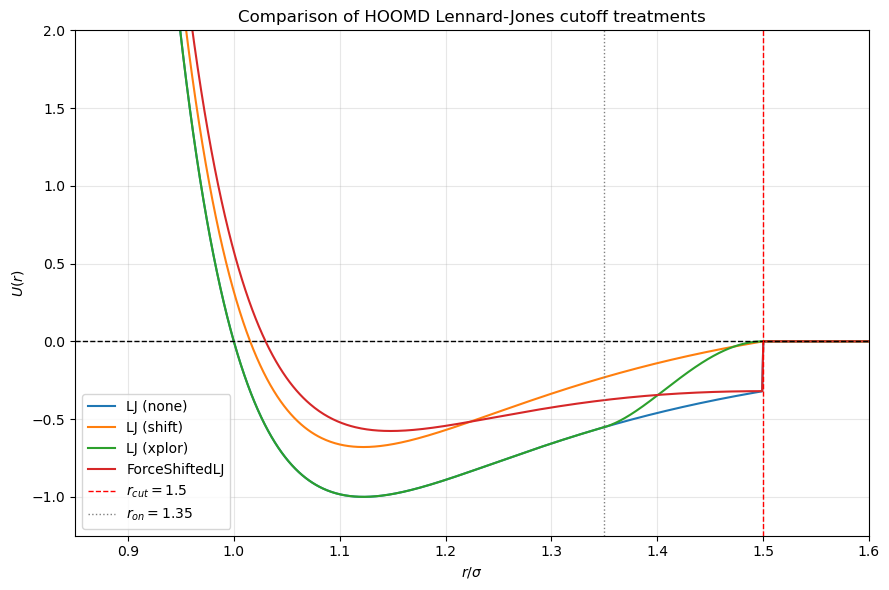

Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_mode_comparison.png


In [13]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import hoomd
import md_Helpers


# ============================================================
# Output location
# ============================================================

mdsims_root = Path(md_Helpers.__file__).resolve().parent.parent

output_path = (
    mdsims_root
    / "Plots"
    / "HOOMD"
    / "PairPotentials"
    / "lj_cutoff_mode_comparison.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Parameters
# ============================================================

r_cut = 1.5
r_on = 1.35

epsilon = 1.0
sigma = 1.0

r_values = np.linspace(0.85, r_cut+.1, 700)


# ============================================================
# mode = none
# ============================================================

cell_none = hoomd.md.nlist.Cell(buffer=0.4)

lj_none = hoomd.md.pair.LJ(
    nlist=cell_none,
    default_r_cut=r_cut,
    mode="none",
)

lj_none.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# mode = shift
# ============================================================

cell_shift = hoomd.md.nlist.Cell(buffer=0.4)

lj_shift = hoomd.md.pair.LJ(
    nlist=cell_shift,
    default_r_cut=r_cut,
    mode="shift",
)

lj_shift.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# mode = xplor
# ============================================================

cell_xplor = hoomd.md.nlist.Cell(buffer=0.4)

lj_xplor = hoomd.md.pair.LJ(
    nlist=cell_xplor,
    default_r_cut=r_cut,
    mode="xplor",
)

lj_xplor.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}

lj_xplor.r_on[("A", "A")] = r_on


# ============================================================
# ForceShiftedLJ
# ============================================================

cell_force_shifted = hoomd.md.nlist.Cell(buffer=0.4)

lj_force_shifted = hoomd.md.pair.ForceShiftedLJ(
    nlist=cell_force_shifted,
    default_r_cut=r_cut,
)

lj_force_shifted.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# Measure all pair potentials
# ============================================================

U_none = measure_pair_potential(
    pair_force=lj_none,
    r_values=r_values,
    box_length=30,
)

U_shift = measure_pair_potential(
    pair_force=lj_shift,
    r_values=r_values,
    box_length=30,
)

U_xplor = measure_pair_potential(
    pair_force=lj_xplor,
    r_values=r_values,
    box_length=30,
)

U_force_shifted = measure_pair_potential(
    pair_force=lj_force_shifted,
    r_values=r_values,
    box_length=30,
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    r_values,
    U_none,
    label="LJ (none)",
)

ax.plot(
    r_values,
    U_shift,
    label="LJ (shift)",
)

ax.plot(
    r_values,
    U_xplor,
    label="LJ (xplor)",
)

ax.plot(
    r_values,
    U_force_shifted,
    label="ForceShiftedLJ",
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    r_cut,
    color="red",
    linestyle="--",
    linewidth=1,
    label=rf"$r_{{cut}}={r_cut}$",
)

ax.axvline(
    r_on,
    color="gray",
    linestyle=":",
    linewidth=1,
    label=rf"$r_{{on}}={r_on}$",
)

ax.set_xlabel(r"$r/\sigma$")
ax.set_ylabel(r"$U(r)$")

ax.set_title(
    "Comparison of HOOMD Lennard-Jones cutoff treatments"
)

ax.set_ylim(-1.25, 2.0)

ax.set_xlim(
    r_values.min(),
    r_values.max(),
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()


# ============================================================
# Save and display
# ============================================================

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", output_path)

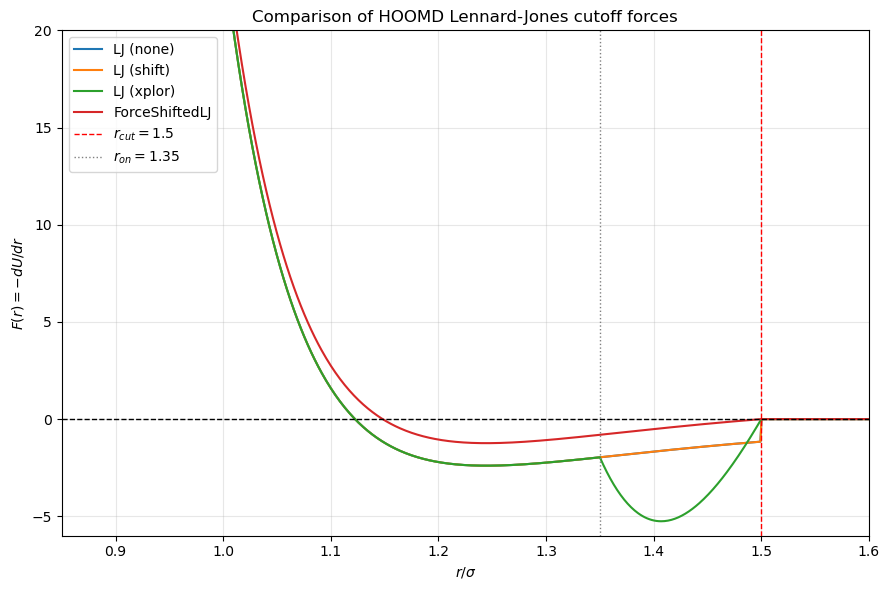

Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_force_comparison.png


In [14]:
# ============================================================
# Measure and plot radial pair forces
# ============================================================

def measure_pair_force(
    pair_force,
    r_values,
    box_length=30,
    particle_type="A",
    seed=1,
):
    """
    Measure F(r) = -dU/dr directly from the force on two particles.

    Positive values indicate repulsion; negative values indicate attraction.
    """

    radial_forces = []

    for r in r_values:
        snap = hoomd.Snapshot()
        snap.particles.N = 2
        snap.particles.types = [particle_type]
        snap.particles.typeid[:] = [0, 0]
        snap.configuration.box = [
            box_length,
            box_length,
            box_length,
            0,
            0,
            0,
        ]

        snap.particles.position[:] = [
            [-r / 2, 0, 0],
            [ r / 2, 0, 0],
        ]

        sim_test = hoomd.Simulation(
            device=hoomd.device.CPU(),
            seed=seed,
        )
        sim_test.create_state_from_snapshot(snap)

        integrator = hoomd.md.Integrator(dt=0.005)
        integrator.forces.append(pair_force)
        sim_test.operations.integrator = integrator

        sim_test.run(0)

        # Particle 0 is on the left. Its outward radial direction is -x.
        radial_forces.append(-float(pair_force.forces[0][0]))

    return np.asarray(radial_forces)


F_none = measure_pair_force(lj_none, r_values)
F_shift = measure_pair_force(lj_shift, r_values)
F_xplor = measure_pair_force(lj_xplor, r_values)
F_force_shifted = measure_pair_force(lj_force_shifted, r_values)


# ============================================================
# Plot
# ============================================================

force_output_path = output_path.with_name(
    "lj_cutoff_force_comparison.png"
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(r_values, F_none, label="LJ (none)")
ax.plot(r_values, F_shift, label="LJ (shift)")
ax.plot(r_values, F_xplor, label="LJ (xplor)")
ax.plot(
    r_values,
    F_force_shifted,
    label="ForceShiftedLJ",
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    r_cut,
    color="red",
    linestyle="--",
    linewidth=1,
    label=rf"$r_{{cut}}={r_cut}$",
)

ax.axvline(
    r_on,
    color="gray",
    linestyle=":",
    linewidth=1,
    label=rf"$r_{{on}}={r_on}$",
)

ax.set_xlabel(r"$r/\sigma$")
ax.set_ylabel(r"$F(r)=-dU/dr$")
ax.set_title(
    "Comparison of HOOMD Lennard-Jones cutoff forces"
)

ax.set_xlim(
    r_values.min(),
    r_values.max(),
)
ax.set_ylim(-6, 20)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    force_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", force_output_path)

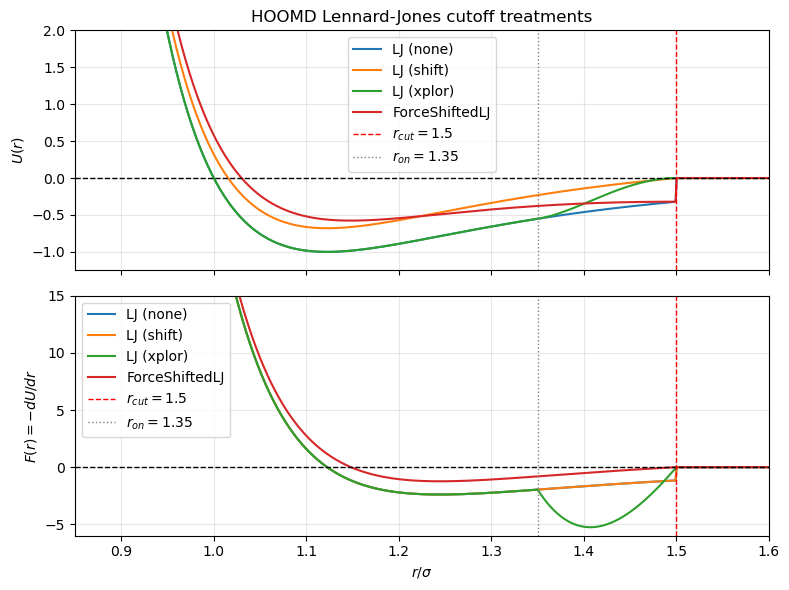

Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_potential_force_comparison.png


In [15]:
# Save in the same directory as the existing plot
stacked_output_path = output_path.with_name(
    "lj_cutoff_potential_force_comparison.png"
)

fig, (ax_U, ax_F) = plt.subplots(
    2,
    1,
    figsize=(8, 6),
    sharex=True,
)

curves = [
    ("LJ (none)", U_none, F_none),
    ("LJ (shift)", U_shift, F_shift),
    ("LJ (xplor)", U_xplor, F_xplor),
    ("ForceShiftedLJ", U_force_shifted, F_force_shifted),
]

for label, potential, force in curves:
    ax_U.plot(r_values, potential, label=label)
    ax_F.plot(r_values, force, label=label)

for ax in (ax_U, ax_F):
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(
        r_cut,
        color="red",
        linestyle="--",
        linewidth=1,
        label=rf"$r_{{cut}}={r_cut}$",
    )
    ax.axvline(
        r_on,
        color="gray",
        linestyle=":",
        linewidth=1,
        label=rf"$r_{{on}}={r_on}$",
    )
    ax.grid(alpha=0.3)
    ax.legend()

ax_U.set_ylabel(r"$U(r)$")
ax_U.set_ylim(-1.25, 2.0)
ax_U.set_title(
    "HOOMD Lennard-Jones cutoff treatments"
)

ax_F.set_xlabel(r"$r/\sigma$")
ax_F.set_ylabel(r"$F(r)=-dU/dr$")
ax_F.set_ylim(-6, 15)

ax_F.set_xlim(
    r_values.min(),
    r_values.max(),
)

fig.tight_layout()

fig.savefig(
    stacked_output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", stacked_output_path)

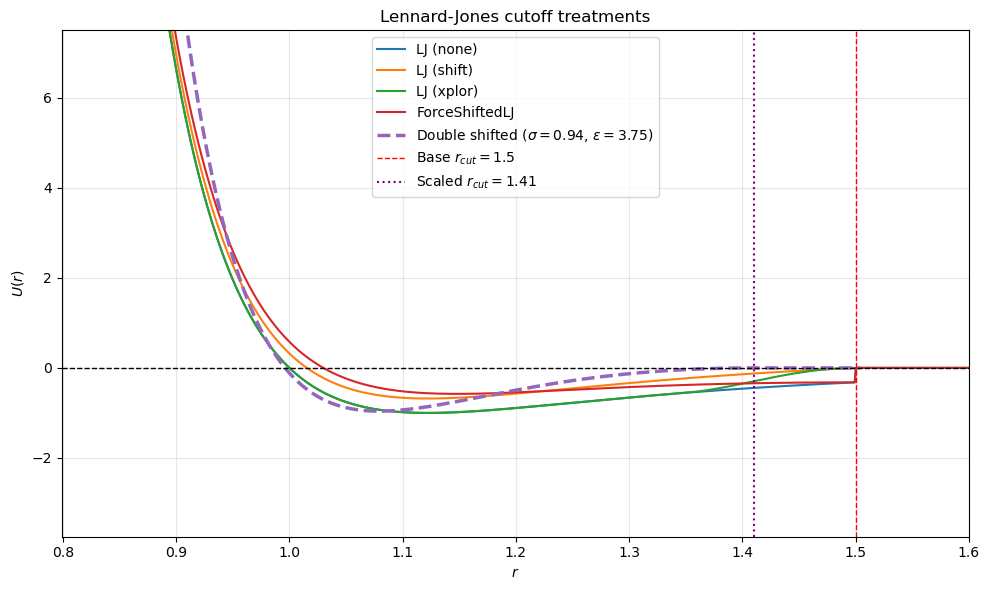

sigma_double: 0.94
epsilon_double: 3.75
r_cut_double: 1.41
Saved: /home/pnichols/MDsims/Plots/HOOMD/PairPotentials/lj_cutoff_mode_comparison.png


In [16]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import hoomd
import md_Helpers


# ============================================================
# User-controlled scaling
# ============================================================

sig_scale = .94
epsilon_scale = 3.75


# ============================================================
# Output location
# ============================================================

mdsims_root = Path(md_Helpers.__file__).resolve().parent.parent

output_path = (
    mdsims_root
    / "Plots"
    / "HOOMD"
    / "PairPotentials"
    / "lj_cutoff_mode_comparison.png"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Base parameters
# ============================================================

sigma = 1.0
epsilon = 1.0

r_cut = 1.5 * sigma
r_on = 1.35 * sigma

# Distances used for the ordinary LJ curves
r_values = np.linspace(
    0.85 * sigma,
    r_cut + 0.1 * sigma,
    700,
)


# ============================================================
# Double-shifted parameters
# ============================================================

sigma_double = sig_scale * sigma
epsilon_double = epsilon_scale * epsilon

# Preserve r_cut / sigma = 1.5 when sigma changes
r_cut_double = 1.5 * sigma_double

# To keep the physical cutoff fixed instead, use:
# r_cut_double = r_cut

r_values_double = np.linspace(
    0.85 * sigma_double,
    r_cut_double + 0.1 * sigma_double,
    700,
)


# ============================================================
# LJ: mode = none
# ============================================================

lj_none = hoomd.md.pair.LJ(
    nlist=hoomd.md.nlist.Cell(buffer=0.4),
    default_r_cut=r_cut,
    mode="none",
)

lj_none.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# LJ: mode = shift
# ============================================================

lj_shift = hoomd.md.pair.LJ(
    nlist=hoomd.md.nlist.Cell(buffer=0.4),
    default_r_cut=r_cut,
    mode="shift",
)

lj_shift.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# LJ: mode = xplor
# ============================================================

lj_xplor = hoomd.md.pair.LJ(
    nlist=hoomd.md.nlist.Cell(buffer=0.4),
    default_r_cut=r_cut,
    mode="xplor",
)

lj_xplor.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}

lj_xplor.r_on[("A", "A")] = r_on


# ============================================================
# ForceShiftedLJ
# ============================================================

lj_force_shifted = hoomd.md.pair.ForceShiftedLJ(
    nlist=hoomd.md.nlist.Cell(buffer=0.4),
    default_r_cut=r_cut,
)

lj_force_shifted.params[("A", "A")] = {
    "epsilon": epsilon,
    "sigma": sigma,
}


# ============================================================
# Force- and potential-shifted LJ table
# ============================================================

table_width = 20000
table_r_min = 0.5 * sigma_double

r_table = np.linspace(
    table_r_min,
    r_cut_double,
    table_width,
    endpoint=False,
)

# Ordinary LJ potential and force
sr6 = (sigma_double / r_table) ** 6
sr12 = sr6**2

V_lj = 4 * epsilon_double * (sr12 - sr6)

F_lj = (
    24
    * epsilon_double
    / r_table
    * (2 * sr12 - sr6)
)

# Values at the cutoff
sr6_cut = (sigma_double / r_cut_double) ** 6
sr12_cut = sr6_cut**2

V_cut = (
    4
    * epsilon_double
    * (sr12_cut - sr6_cut)
)

F_cut = (
    24
    * epsilon_double
    / r_cut_double
    * (2 * sr12_cut - sr6_cut)
)

# Shift force and potential to zero at the cutoff
U_double_shifted = (
    V_lj
    - V_cut
    + (r_table - r_cut_double) * F_cut
)

F_double_shifted = F_lj - F_cut

lj_double_shifted = hoomd.md.pair.Table(
    nlist=hoomd.md.nlist.Cell(buffer=0.4),
    default_r_cut=r_cut_double,
)

lj_double_shifted.params[("A", "A")] = {
    "r_min": table_r_min,
    "U": U_double_shifted,
    "F": F_double_shifted,
}


# ============================================================
# Measure potentials
# ============================================================

U_none = measure_pair_potential(
    lj_none,
    r_values,
)

U_shift = measure_pair_potential(
    lj_shift,
    r_values,
)

U_xplor = measure_pair_potential(
    lj_xplor,
    r_values,
)

U_force_shifted = measure_pair_potential(
    lj_force_shifted,
    r_values,
)

U_double_shifted_measured = measure_pair_potential(
    lj_double_shifted,
    r_values_double,
)


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    r_values,
    U_none,
    label="LJ (none)",
)

ax.plot(
    r_values,
    U_shift,
    label="LJ (shift)",
)

ax.plot(
    r_values,
    U_xplor,
    label="LJ (xplor)",
)

ax.plot(
    r_values,
    U_force_shifted,
    label="ForceShiftedLJ",
)

ax.plot(
    r_values_double,
    U_double_shifted_measured,
    linestyle="--",
    linewidth=2.5,
    label=(
        "Double shifted "
        rf"($\sigma={sigma_double:g}$, "
        rf"$\epsilon={epsilon_double:g}$)"
    ),
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axvline(
    r_cut,
    color="red",
    linestyle="--",
    linewidth=1,
    label=rf"Base $r_{{cut}}={r_cut:g}$",
)

ax.axvline(
    r_cut_double,
    color="purple",
    linestyle=":",
    linewidth=1.5,
    label=rf"Scaled $r_{{cut}}={r_cut_double:g}$",
)

ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$U(r)$")

ax.set_title(
    "Lennard-Jones cutoff treatments"
)

energy_plot_scale = max(
    1.0,
    abs(epsilon_scale),
)

ax.set_ylim(
    -energy_plot_scale,
    2.0 * energy_plot_scale,
)

ax.set_xlim(
    min(r_values.min(), r_values_double.min()),
    max(r_values.max(), r_values_double.max()),
)

ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("sigma_double:", sigma_double)
print("epsilon_double:", epsilon_double)
print("r_cut_double:", r_cut_double)
print("Saved:", output_path)